# Election Data Science Analysis: From Data Understanding to Dashboard Insights

This notebook documents the data science phase behind the Streamlit election dashboard.

The analysis follows this story:

1. Understand the prepared recent election dataset structure and quality.
2. Clean impossible polling-unit records, especially turnout rates above 100%.
3. Engineer analytical features such as turnout rate, vote share, winner margin, and split-ticket gaps.
4. Compare the recent election with the previous 2566 election.
5. Export focused tables that explain and support the Streamlit visualizations.

The main dashboard story is therefore: after understanding the current data, we compare it with ปี66 to identify vote shifts, winner changes, constituency vs party-list differences, and local strongholds.


In [90]:
# Optional dependency for the clustering section.
# In Jupyter, uncomment this if scikit-learn is not installed:
# %pip install scikit-learn


In [91]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
from pathlib import Path

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')


THAI_FONT_NAME = 'Bai Jamjuree'
THAI_FONT_FALLBACKS = ['Bai Jamjuree', 'Noto Sans Thai', 'Noto Looped Thai', 'Tahoma', 'sans-serif']
for font_path in [
    os.path.expanduser('~/.local/share/fonts/BaiJamjuree-Regular.ttf'),
    os.path.expanduser('~/.local/share/fonts/BaiJamjuree-Bold.ttf'),
    '/usr/share/fonts/truetype/noto/NotoSansThai-Regular.ttf',
    '/usr/share/fonts/truetype/noto/NotoSansThai-Bold.ttf',
]:
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)

available_fonts = {font.name for font in fm.fontManager.ttflist}
for font_name in THAI_FONT_FALLBACKS:
    if font_name in available_fonts:
        plt.rcParams['font.family'] = font_name
        break
plt.rcParams['axes.unicode_minus'] = False
print('Matplotlib Thai font:', plt.rcParams['font.family'])

DATA_DIR = Path('recent_data')
CONSTITUENCY_PATH = DATA_DIR / 'constituency_wide.csv'
PARTY_LIST_PATH = DATA_DIR / 'party_list_wide.csv'

PREVIOUS_DATA_DIR = Path('previous_data')
PREVIOUS_CONSTITUENCY_PATH = PREVIOUS_DATA_DIR / 'ubon_2_constituency_2566.csv'
PREVIOUS_PARTY_LIST_PATH = PREVIOUS_DATA_DIR / 'ubon_2_partylist_2566.csv'
PREVIOUS_FULL_SCORES_PATH = PREVIOUS_DATA_DIR / 'election_scores_2566.csv'

if not CONSTITUENCY_PATH.exists():
    CONSTITUENCY_PATH = Path('/mnt/data/constituency_wide.csv')
if not PARTY_LIST_PATH.exists():
    PARTY_LIST_PATH = Path('/mnt/data/party_list_wide.csv')
if not PREVIOUS_CONSTITUENCY_PATH.exists():
    PREVIOUS_CONSTITUENCY_PATH = Path('/mnt/data/ubon_2_constituency_2566.csv')
if not PREVIOUS_PARTY_LIST_PATH.exists():
    PREVIOUS_PARTY_LIST_PATH = Path('/mnt/data/ubon_2_partylist_2566.csv')
if not PREVIOUS_FULL_SCORES_PATH.exists():
    PREVIOUS_FULL_SCORES_PATH = Path('/mnt/data/election_scores_2566.csv')

Matplotlib Thai font: ['Bai Jamjuree']


## 1. Load data

In [92]:
const_wide = pd.read_csv(CONSTITUENCY_PATH)
party_wide = pd.read_csv(PARTY_LIST_PATH)

def drop_impossible_rate_units(df):
    if not {'eligible_voters', 'turnout'}.issubset(df.columns):
        return df.copy()
    out = df.copy()
    eligible = pd.to_numeric(out['eligible_voters'], errors='coerce')
    turnout = pd.to_numeric(out['turnout'], errors='coerce')
    turnout_rate = turnout / eligible.replace(0, np.nan)
    impossible_rate = turnout_rate.gt(1).fillna(False)
    if 'spoiled_ballots' in out.columns:
        spoiled = pd.to_numeric(out['spoiled_ballots'], errors='coerce')
        spoiled_rate = spoiled / turnout.replace(0, np.nan)
        impossible_rate = impossible_rate | spoiled_rate.gt(1).fillna(False)
    dropped = int(impossible_rate.sum())
    cleaned = out[~impossible_rate].copy()
    return cleaned, dropped

const_wide, const_dropped_impossible_turnout = drop_impossible_rate_units(const_wide)
party_wide, party_dropped_impossible_turnout = drop_impossible_rate_units(party_wide)

print('Dropped impossible rate rows - constituency:', const_dropped_impossible_turnout)
print('Dropped impossible rate rows - party-list:', party_dropped_impossible_turnout)

print('Constituency:', const_wide.shape)
print('Party-list:', party_wide.shape)

display(const_wide.head())
display(party_wide.head())

Dropped impossible rate rows - constituency: 17
Dropped impossible rate rows - party-list: 11
Constituency: (204, 38)
Party-list: (142, 132)


,province,constituency,amphoe,tambon,unit,form_type,eligible_voters,turnout,ballots_allocated,ballots_used,valid_ballots,spoiled_ballots,abstain_ballots,ballots_remaining,val_total_votes_in_table,val_effective_vote_sum,val_valid_ballots,val_vote_diff,กล้าธรรม_votes,กล้าธรรม_votes_th,ภูมิใจไทย_votes,ภูมิใจไทย_votes_th,เพื่อไทย_votes,เพื่อไทย_votes_th,ประชาชน_votes,ประชาชน_votes_th,ไทรวมพลัง_votes,ไทรวมพลัง_votes_th,ประชาธิปไตยใหม่_votes,ประชาธิปไตยใหม่_votes_th,พลังประชารัฐ_votes,พลังประชารัฐ_votes_th,ประชาธิปัตย์_votes,ประชาธิปัตย์_votes_th,เศรษฐกิจ_votes,เศรษฐกิจ_votes_th,ไทยก้าวใหม่_votes,ไทยก้าวใหม่_votes_th
0,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,1,constituency,402.000,316.000,400.000,316.000,295.000,7.000,14.000,84.000,335,335,295,40,57,57,11,0,33,33,31,0,195,0,1,1,1,1,0,0,3,3,3,3
1,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,11,constituency,324.000,274.000,320.000,274.000,257.000,9.000,8.000,46.000,257,257,257,0,50,50,4,4,18,18,34,34,148,0,1,1,0,0,0,0,2,0,0,0
2,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,2,constituency,635.000,472.000,620.000,472.000,453.000,9.000,12.000,148.000,453,453,453,0,118,118,7,7,12,12,50,50,253,253,2,2,0,0,4,4,5,5,2,2
3,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,3,constituency,548.000,443.000,540.000,443.000,401.000,26.000,16.000,97.000,401,401,401,0,84,84,6,6,26,16,43,43,233,233,0,0,0,0,3,3,4,4,2,2
4,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,4,constituency,657.000,512.000,640.000,512.000,477.000,14.000,21.000,128.000,469,469,477,-8,117,0,13,13,16,16,67,67,251,259,0,0,0,0,2,2,2,2,1,1


,province,constituency,amphoe,tambon,unit,form_type,eligible_voters,turnout,ballots_allocated,ballots_used,valid_ballots,spoiled_ballots,abstain_ballots,ballots_remaining,val_total_votes_in_table,val_effective_vote_sum,val_valid_ballots,val_vote_diff,ไทยทรัพย์ทวี_votes,ไทยทรัพย์ทวี_votes_th,เพื่อชาติไทย_votes,เพื่อชาติไทย_votes_th,ใหม่_votes,ใหม่_votes_th,มิติใหม่_votes,มิติใหม่_votes_th,รวมใจไทย_votes,รวมใจไทย_votes_th,รวมไทยสร้างชาติ_votes,รวมไทยสร้างชาติ_votes_th,พลวัต_votes,พลวัต_votes_th,ประชาธิปไตยใหม่_votes,ประชาธิปไตยใหม่_votes_th,เพื่อไทย_votes,เพื่อไทย_votes_th,ทางเลือกใหม่_votes,ทางเลือกใหม่_votes_th,เศรษฐกิจ_votes,เศรษฐกิจ_votes_th,เสรีรวมไทย_votes,เสรีรวมไทย_votes_th,รวมพลังประชาชน_votes,รวมพลังประชาชน_votes_th,ท้องที่ไทย_votes,ท้องที่ไทย_votes_th,อนาคตไทย_votes,อนาคตไทย_votes_th,พลังเพื่อไทย_votes,พลังเพื่อไทย_votes_th,ไทยชนะ_votes,ไทยชนะ_votes_th,พลังสังคมใหม่_votes,พลังสังคมใหม่_votes_th,สังคมประชาธิปไตยไทย_votes,สังคมประชาธิปไตยไทย_votes_th,ฟิวชัน_votes,ฟิวชัน_votes_th,ไทรวมพลัง_votes,ไทรวมพลัง_votes_th,ก้าวอิสระ_votes,ก้าวอิสระ_votes_th,ปวงชนไทย_votes,ปวงชนไทย_votes_th,วิชชั่นใหม่_votes,วิชชั่นใหม่_votes_th,เพื่อชีวิตใหม่_votes,เพื่อชีวิตใหม่_votes_th,คลองไทย_votes,คลองไทย_votes_th,ประชาธิปัตย์_votes,ประชาธิปัตย์_votes_th,ไทยก้าวหน้า_votes,ไทยก้าวหน้า_votes_th,ไทยภักดี_votes,ไทยภักดี_votes_th,แรงงานสร้างชาติ_votes,แรงงานสร้างชาติ_votes_th,ประชากรไทย_votes,ประชากรไทย_votes_th,ครูไทยเพื่อประชาชน_votes,ครูไทยเพื่อประชาชน_votes_th,ประชาชาติ_votes,ประชาชาติ_votes_th,สร้างอนาคตไทย_votes,สร้างอนาคตไทย_votes_th,รักชาติ_votes,รักชาติ_votes_th,ไทยพร้อม_votes,ไทยพร้อม_votes_th,ภูมิใจไทย_votes,ภูมิใจไทย_votes_th,พลังธรรมใหม่_votes,พลังธรรมใหม่_votes_th,กรีน_votes,กรีน_votes_th,ไทยธรรม_votes,ไทยธรรม_votes_th,แผ่นดินธรรม_votes,แผ่นดินธรรม_votes_th,กล้าธรรม_votes,กล้าธรรม_votes_th,พลังประชารัฐ_votes,พลังประชารัฐ_votes_th,โอกาสใหม่_votes,โอกาสใหม่_votes_th,เป็นธรรม_votes,เป็นธรรม_votes_th,ประชาชน_votes,ประชาชน_votes_th,ประชาไทย_votes,ประชาไทย_votes_th,ไทยสร้างไทย_votes,ไทยสร้างไทย_votes_th,ไทยก้าวใหม่_votes,ไทยก้าวใหม่_votes_th,ประชาอาสาชาติ_votes,ประชาอาสาชาติ_votes_th,พร้อม_votes,พร้อม_votes_th,เครือข่ายชาวนาแห่งประเทศไทย_votes,เครือข่ายชาวนาแห่งประเทศไทย_votes_th,ไทยพิทักษ์ธรรม_votes,ไทยพิทักษ์ธรรม_votes_th,ความหวังใหม่_votes,ความหวังใหม่_votes_th,ไทยรวมไทย_votes,ไทยรวมไทย_votes_th,เพื่อบ้านเมือง_votes,เพื่อบ้านเมือง_votes_th,พลังไทยรักชาติ_votes,พลังไทยรักชาติ_votes_th
0,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,3,party_list,548.000,443.000,540.000,443.000,406.000,25.000,12.000,97.000,272,272,406,-134,5,0,5,0,2,0,1,1,18,0,2,0,1,1,4,0,54,0,2,0,12,0,4,0,4,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,140,0,1,1,0,0,2,2,1,1,0,0,7,7,0,0,1,1,2,2,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,4,party_list,651.000,512.000,640.000,512.000,464.000,27.000,21.000,128.000,269,269,464,-195,4,0,6,6,4,0,0,0,19,0,6,6,0,0,4,0,73,73,3,3,12,12,3,3,6,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,105,0,0,0,0,0,3,3,1,1,1,1,15,15,1,1,1,1,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,5,party_list,590.000,482.000,580.000,482.000,447.000,23.000,12.000,98.000,447,447,447,0,26,26,4,4,2,2,2,2,11,0,4,4,0,0,0,0,53,53,3,3,24,23,1,1,3,3,0,0,0,0,3,3,1,1,0,0,0,0,1,1,92,92,0,0,0,0,2,2,0,0,0,0,7,7,2,2,1,1,3,3,0,0,0,0,3,3,1,1,0,0,0,0,34,34,1,1,0,0,1,1,1,1,48,48,0,0,0,0,1,1,103,0,0,0,5,5,2,2,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1
3,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,9,party_list,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,อุบลราชธานี,2,ตำบลปะอาว,ตำบลปะอาว,1,party_list,370.000,293.000,360.000,293.000,252.000,15.000,26.000,67.000,252,252,252,0,0,0,0,0,0,0,0,0,0,0,0,0,0

## 2. Basic schema and quality check

In [93]:
base_cols = [
    'province', 'constituency', 'amphoe', 'tambon', 'unit', 'form_type',
    'eligible_voters', 'turnout', 'ballots_allocated', 'ballots_used',
    'valid_ballots', 'spoiled_ballots', 'abstain_ballots', 'ballots_remaining',
    'val_total_votes_in_table', 'val_effective_vote_sum', 'val_valid_ballots', 'val_vote_diff'
]

for name, df in [('constituency', const_wide), ('party_list', party_wide)]:
    print(' ' + '='*80)
    print(name)
    print('='*80)
    print(df.info())
    print('Missing values in base columns:')
    display(df[[c for c in base_cols if c in df.columns]].isna().sum().to_frame('missing'))

constituency
<class 'pandas.DataFrame'>
Index: 204 entries, 0 to 220
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   province                  204 non-null    str    
 1   constituency              204 non-null    int64  
 2   amphoe                    204 non-null    str    
 3   tambon                    204 non-null    str    
 4   unit                      204 non-null    int64  
 5   form_type                 204 non-null    str    
 6   eligible_voters           202 non-null    float64
 7   turnout                   180 non-null    float64
 8   ballots_allocated         202 non-null    float64
 9   ballots_used              202 non-null    float64
 10  valid_ballots             202 non-null    float64
 11  spoiled_ballots           201 non-null    float64
 12  abstain_ballots           198 non-null    float64
 13  ballots_remaining         202 non-null    float64
 14  val_total_vot

,missing
province,0
constituency,0
amphoe,0
tambon,0
unit,0
form_type,0
eligible_voters,2
turnout,24
ballots_allocated,2
ballots_used,2


party_list
<class 'pandas.DataFrame'>
Index: 142 entries, 0 to 152
Columns: 132 entries, province to พลังไทยรักชาติ_votes_th
dtypes: float64(8), int64(120), str(4)
memory usage: 147.5 KB
None
Missing values in base columns:


,missing
province,0
constituency,0
amphoe,0
tambon,0
unit,0
form_type,0
eligible_voters,5
turnout,18
ballots_allocated,5
ballots_used,5


In [94]:
def detect_vote_columns(df):
    return [c for c in df.columns if c.endswith('_votes') and not c.endswith('_votes_th')]

const_vote_cols = detect_vote_columns(const_wide)
party_vote_cols = detect_vote_columns(party_wide)

print('Constituency vote columns:', len(const_vote_cols))
print(const_vote_cols)
print('Party-list vote columns:', len(party_vote_cols))
print(party_vote_cols[:20], '...')

Constituency vote columns: 10
['กล้าธรรม_votes', 'ภูมิใจไทย_votes', 'เพื่อไทย_votes', 'ประชาชน_votes', 'ไทรวมพลัง_votes', 'ประชาธิปไตยใหม่_votes', 'พลังประชารัฐ_votes', 'ประชาธิปัตย์_votes', 'เศรษฐกิจ_votes', 'ไทยก้าวใหม่_votes']
Party-list vote columns: 57
['ไทยทรัพย์ทวี_votes', 'เพื่อชาติไทย_votes', 'ใหม่_votes', 'มิติใหม่_votes', 'รวมใจไทย_votes', 'รวมไทยสร้างชาติ_votes', 'พลวัต_votes', 'ประชาธิปไตยใหม่_votes', 'เพื่อไทย_votes', 'ทางเลือกใหม่_votes', 'เศรษฐกิจ_votes', 'เสรีรวมไทย_votes', 'รวมพลังประชาชน_votes', 'ท้องที่ไทย_votes', 'อนาคตไทย_votes', 'พลังเพื่อไทย_votes', 'ไทยชนะ_votes', 'พลังสังคมใหม่_votes', 'สังคมประชาธิปไตยไทย_votes', 'ฟิวชัน_votes'] ...


## 3. Convert wide format to long format

The long format is easier for grouping, ranking, winner detection, vote-share calculation, and dashboard export.

In [95]:
def wide_to_long(df, election_type):
    vote_cols = detect_vote_columns(df)
    id_cols = [c for c in df.columns if c not in vote_cols and not c.endswith('_votes_th')]
    long_df = df.melt(
        id_vars=id_cols,
        value_vars=vote_cols,
        var_name='party',
        value_name='votes'
    )
    long_df['party'] = long_df['party'].str.replace('_votes$', '', regex=True)
    long_df['votes'] = pd.to_numeric(long_df['votes'], errors='coerce').fillna(0)
    long_df['election_type'] = election_type
    long_df['polling_station_id'] = (
        long_df['province'].astype(str) + '|' +
        long_df['constituency'].astype(str) + '|' +
        long_df['amphoe'].astype(str) + '|' +
        long_df['tambon'].astype(str) + '|' +
        long_df['unit'].astype(str)
    )
    return long_df

const_long = wide_to_long(const_wide, 'constituency')
party_long = wide_to_long(party_wide, 'party_list')
all_long = pd.concat([const_long, party_long], ignore_index=True)

print(const_long.shape, party_long.shape, all_long.shape)
display(all_long.head())

(2040, 22) (8094, 22) (10134, 22)


,province,constituency,amphoe,tambon,unit,form_type,eligible_voters,turnout,ballots_allocated,ballots_used,valid_ballots,spoiled_ballots,abstain_ballots,ballots_remaining,val_total_votes_in_table,val_effective_vote_sum,val_valid_ballots,val_vote_diff,party,votes,election_type,polling_station_id
0,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,1,constituency,402.000,316.000,400.000,316.000,295.000,7.000,14.000,84.000,335,335,295,40,กล้าธรรม,57,constituency,อุบลราชธานี|2|ตำบลขี้เหล็ก|ตำบลขี้เหล็ก|1
1,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,11,constituency,324.000,274.000,320.000,274.000,257.000,9.000,8.000,46.000,257,257,257,0,กล้าธรรม,50,constituency,อุบลราชธานี|2|ตำบลขี้เหล็ก|ตำบลขี้เหล็ก|11
2,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,2,constituency,635.000,472.000,620.000,472.000,453.000,9.000,12.000,148.000,453,453,453,0,กล้าธรรม,118,constituency,อุบลราชธานี|2|ตำบลขี้เหล็ก|ตำบลขี้เหล็ก|2
3,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,3,constituency,548.000,443.000,540.000,443.000,401.000,26.000,16.000,97.000,401,401,401,0,กล้าธรรม,84,constituency,อุบลราชธานี|2|ตำบลขี้เหล็ก|ตำบลขี้เหล็ก|3
4,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,4,constituency,657.000,512.000,640.000,512.000,477.000,14.000,21.000,128.000,469,469,477,-8,กล้าธรรม,117,constituency,อุบลราชธานี|2|ตำบลขี้เหล็ก|ตำบลขี้เหล็ก|4


## 4. Feature engineering

In [96]:
def add_station_features(df):
    out = df.copy()
    numeric_cols = [
        'eligible_voters', 'turnout', 'ballots_allocated', 'ballots_used',
        'valid_ballots', 'spoiled_ballots', 'abstain_ballots', 'ballots_remaining',
        'val_total_votes_in_table', 'val_effective_vote_sum', 'val_valid_ballots', 'val_vote_diff'
    ]
    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')

    out['turnout_rate'] = out['turnout'] / out['eligible_voters']
    out['valid_rate'] = out['valid_ballots'] / out['turnout']
    out['spoiled_rate'] = out['spoiled_ballots'] / out['turnout']
    out['abstain_rate'] = out['abstain_ballots'] / out['turnout']
    out['unused_ballot_rate'] = out['ballots_remaining'] / out['ballots_allocated']
    out['ocr_vote_diff_abs'] = out['val_vote_diff'].abs() if 'val_vote_diff' in out.columns else np.nan
    return out

const_station = add_station_features(const_wide)
party_station = add_station_features(party_wide)

for name, df in [('constituency', const_station), ('party_list', party_station)]:
    print(' ' + name)
    display(df[['eligible_voters','turnout','turnout_rate','valid_rate','spoiled_rate','abstain_rate','ocr_vote_diff_abs']].describe())

 constituency


,eligible_voters,turnout,turnout_rate,valid_rate,spoiled_rate,abstain_rate,ocr_vote_diff_abs
count,202.000,180.000,180.000,180.000,180.000,177.000,204.000
mean,487.926,314.528,0.657,1.073,0.032,0.045,9.863
std,157.270,111.046,0.153,1.019,0.032,0.067,35.523
min,75.000,12.000,0.060,0.000,0.000,0.000,0.000
25%,374.000,233.500,0.597,0.907,0.016,0.011,0.000
50%,502.000,320.000,0.668,0.950,0.026,0.023,0.000
75%,581.750,393.250,0.732,0.971,0.036,0.054,3.000
max,913.000,608.000,1.000,10.370,0.296,0.473,419.000


 party_list


,eligible_voters,turnout,turnout_rate,valid_rate,spoiled_rate,abstain_rate,ocr_vote_diff_abs
count,137.000,124.000,124.000,124.000,123.000,120.000,142.000
mean,515.292,326.371,0.649,0.980,0.058,0.035,58.225
std,164.534,115.198,0.133,0.353,0.082,0.032,91.940
min,110.000,73.000,0.143,0.811,0.000,0.000,0.000
25%,410.000,251.250,0.606,0.906,0.035,0.017,4.000
50%,520.000,333.500,0.667,0.928,0.046,0.027,27.500
75%,590.000,405.500,0.728,0.946,0.062,0.041,85.750
max,985.000,621.000,1.000,4.506,0.897,0.260,861.000


In [97]:
def summarize_station_winners(long_df):
    work = long_df.copy()
    work['total_party_votes_at_station'] = work.groupby('polling_station_id')['votes'].transform('sum')
    work['vote_share'] = np.where(
        work['total_party_votes_at_station'] > 0,
        work['votes'] / work['total_party_votes_at_station'],
        0
    )
    ranked = work.sort_values(['polling_station_id', 'votes'], ascending=[True, False]).copy()
    ranked['rank'] = ranked.groupby('polling_station_id')['votes'].rank(method='first', ascending=False)

    top2 = ranked[ranked['rank'].isin([1, 2])].copy()
    winners = top2[top2['rank'] == 1].copy()
    runners = top2[top2['rank'] == 2][['polling_station_id', 'party', 'votes', 'vote_share']].copy()
    runners = runners.rename(columns={
        'party': 'runner_up_party',
        'votes': 'runner_up_votes',
        'vote_share': 'runner_up_share'
    })
    winners = winners.rename(columns={
        'party': 'winner_party',
        'votes': 'winner_votes',
        'vote_share': 'winner_share'
    })
    winners = winners.merge(runners, on='polling_station_id', how='left')
    winners['margin_votes'] = winners['winner_votes'] - winners['runner_up_votes']
    winners['margin_share'] = winners['winner_share'] - winners['runner_up_share']
    return winners

const_winners = summarize_station_winners(const_long)
party_winners = summarize_station_winners(party_long)

print(const_winners.shape, party_winners.shape)
display(const_winners[['province','constituency','amphoe','tambon','unit','winner_party','winner_votes','runner_up_party','runner_up_votes','margin_votes','margin_share']].head())

(204, 30) (142, 30)


,province,constituency,amphoe,tambon,unit,winner_party,winner_votes,runner_up_party,runner_up_votes,margin_votes,margin_share
0,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,1,ไทรวมพลัง,195,กล้าธรรม,57,138,0.412
1,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,11,ไทรวมพลัง,148,กล้าธรรม,50,98,0.381
2,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,2,ไทรวมพลัง,253,กล้าธรรม,118,135,0.298
3,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,3,ไทรวมพลัง,233,กล้าธรรม,84,149,0.372
4,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,4,ไทรวมพลัง,251,กล้าธรรม,117,134,0.286


## 5. Overall election summary

In [98]:
def overall_summary(station_df, name):
    return pd.Series({
        'election_type': name,
        'polling_stations': len(station_df),
        'eligible_voters': station_df['eligible_voters'].sum(),
        'turnout': station_df['turnout'].sum(),
        'valid_ballots': station_df['valid_ballots'].sum(),
        'spoiled_ballots': station_df['spoiled_ballots'].sum(),
        'abstain_ballots': station_df['abstain_ballots'].sum(),
        'turnout_rate': station_df['turnout'].sum() / station_df['eligible_voters'].sum(),
        'valid_rate': station_df['valid_ballots'].sum() / station_df['turnout'].sum(),
        'spoiled_rate': station_df['spoiled_ballots'].sum() / station_df['turnout'].sum(),
        'abstain_rate': station_df['abstain_ballots'].sum() / station_df['turnout'].sum(),
        'ocr_abs_diff_total': station_df['ocr_vote_diff_abs'].sum()
    })

summary = pd.DataFrame([
    overall_summary(const_station, 'constituency'),
    overall_summary(party_station, 'party_list')
])
display(summary)

,election_type,polling_stations,eligible_voters,turnout,valid_ballots,spoiled_ballots,abstain_ballots,turnout_rate,valid_rate,spoiled_rate,abstain_rate,ocr_abs_diff_total
0,constituency,204,"98,561.000","56,615.000","60,818.000","1,884.000","2,786.000",0.574,1.074,0.033,0.049,2012
1,party_list,142,"70,595.000","40,470.000","42,362.000","2,542.000","1,435.000",0.573,1.047,0.063,0.035,8268


## 6. Turnout trend: ปี66 vs ปีนี้

This section uses `previous_data/election_scores_2566.csv` to compare turnout in อุบลราชธานี เขต 2 between the previous election and the recent prepared dataset. The goal is to turn basic data understanding into a trend insight: whether voter participation increased or decreased for constituency and party-list ballots.


In [121]:
def turnout_summary_from_recent(station_df, ballot_type):
    eligible = pd.to_numeric(station_df['eligible_voters'], errors='coerce').sum()
    turnout = pd.to_numeric(station_df['turnout'], errors='coerce').sum()
    return {
        'year': 'ปีนี้',
        'ballot_type': ballot_type,
        'polling_units': int(len(station_df)),
        'eligible_voters': eligible,
        'turnout': turnout,
        'turnout_rate': turnout / eligible if eligible else np.nan,
    }

def turnout_summary_from_previous(scores_df, prefix, ballot_type):
    eligible_col = f'{prefix}ผู้มีสิทธิ์'
    turnout_col = f'{prefix}ผู้มาใช้สิทธิ์'
    work = scores_df.copy()
    work[eligible_col] = pd.to_numeric(work[eligible_col], errors='coerce')
    work[turnout_col] = pd.to_numeric(work[turnout_col], errors='coerce')
    turnout_rate = work[turnout_col] / work[eligible_col].replace(0, np.nan)
    work = work[~turnout_rate.gt(1).fillna(False)].copy()
    eligible = work[eligible_col].sum()
    turnout = work[turnout_col].sum()
    return {
        'year': 'ปี66',
        'ballot_type': ballot_type,
        'polling_units': int(len(work)),
        'eligible_voters': eligible,
        'turnout': turnout,
        'turnout_rate': turnout / eligible if eligible else np.nan,
    }

previous_scores_2566 = pd.read_csv(PREVIOUS_FULL_SCORES_PATH)
previous_ubon2_scores = previous_scores_2566[
    previous_scores_2566['province'].astype(str).str.strip().eq('อุบลราชธานี')
    & pd.to_numeric(previous_scores_2566['province_number'], errors='coerce').eq(2)
].copy()

turnout_year_summary = pd.DataFrame([
    turnout_summary_from_previous(previous_ubon2_scores, 'เขต_', 'แบ่งเขต'),
    turnout_summary_from_recent(const_station, 'แบ่งเขต'),
    turnout_summary_from_previous(previous_ubon2_scores, 'บช_', 'บัญชีรายชื่อ'),
    turnout_summary_from_recent(party_station, 'บัญชีรายชื่อ'),
])
turnout_change = turnout_year_summary.pivot(index='ballot_type', columns='year', values='turnout_rate').reset_index()
turnout_change['change_percentage_points'] = (turnout_change['ปีนี้'] - turnout_change['ปี66']) * 100
turnout_change['trend'] = np.where(turnout_change['change_percentage_points'] >= 0, 'increase', 'decrease')

display(turnout_year_summary.assign(turnout_rate_pct=turnout_year_summary['turnout_rate'] * 100))
display(turnout_change)

turnout_rate_matrix = turnout_year_summary.assign(
    turnout_rate_pct=turnout_year_summary['turnout_rate'] * 100
).pivot(
    index='ballot_type',
    columns='year',
    values='turnout_rate_pct'
)[['ปี66', 'ปีนี้']].round(2)

display(turnout_rate_matrix)



,year,ballot_type,polling_units,eligible_voters,turnout,turnout_rate,turnout_rate_pct
0,ปี66,แบ่งเขต,287,"140,649.000","97,997.000",0.697,69.675
1,ปีนี้,แบ่งเขต,204,"98,561.000","56,615.000",0.574,57.442
2,ปี66,บัญชีรายชื่อ,285,"144,110.000","98,235.000",0.682,68.167
3,ปีนี้,บัญชีรายชื่อ,142,"70,595.000","40,470.000",0.573,57.327


year,ballot_type,ปี66,ปีนี้,change_percentage_points,trend
0,บัญชีรายชื่อ,0.682,0.573,-10.840,decrease
1,แบ่งเขต,0.697,0.574,-12.233,decrease


year,ปี66,ปีนี้
ballot_type,,
บัญชีรายชื่อ,68.170,57.330
แบ่งเขต,69.670,57.440


## 6. Party performance analysis

In [100]:
def party_summary(long_df):
    result = long_df.groupby(['election_type', 'party'], as_index=False).agg(
        votes=('votes', 'sum'),
        stations_contested=('polling_station_id', 'nunique')
    )
    total = result.groupby('election_type')['votes'].transform('sum')
    result['vote_share'] = result['votes'] / total
    result = result.sort_values(['election_type', 'votes'], ascending=[True, False])
    return result

party_perf = party_summary(all_long)

display(party_perf.groupby('election_type').head(15))

,election_type,party,votes,stations_contested,vote_share
9,constituency,ไทรวมพลัง,24934,204,0.409
0,constituency,กล้าธรรม,21976,204,0.360
1,constituency,ประชาชน,7512,204,0.123
6,constituency,เพื่อไทย,2549,204,0.042
5,constituency,ภูมิใจไทย,1601,204,0.026
7,constituency,เศรษฐกิจ,841,204,0.014
8,constituency,ไทยก้าวใหม่,701,204,0.011
2,constituency,ประชาธิปัตย์,417,204,0.007
4,constituency,พลังประชารัฐ,255,204,0.004
3,constituency,ประชาธิปไตยใหม่,225,204,0.004


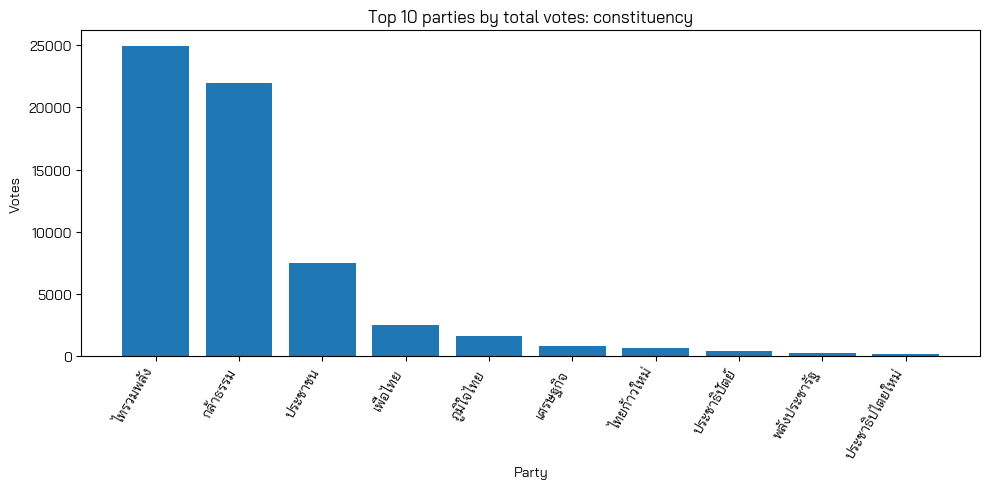

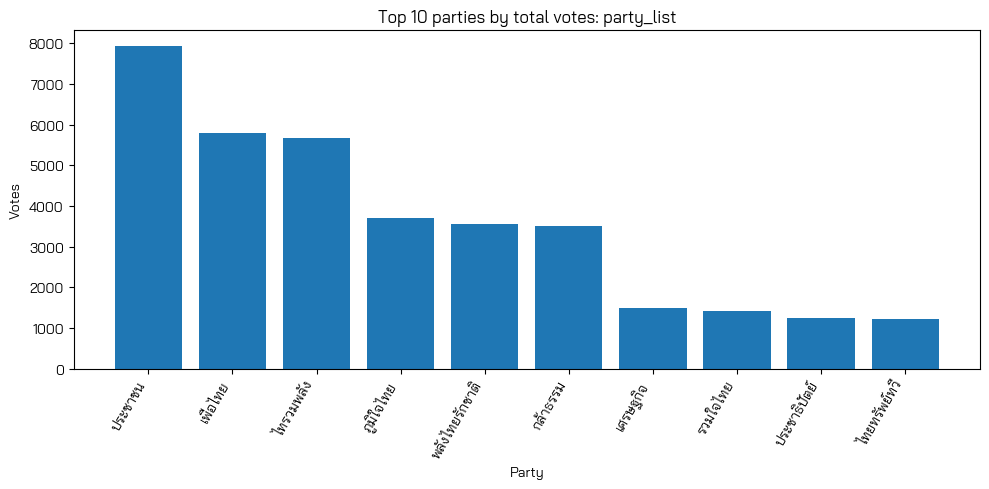

In [101]:
for election_type in party_perf['election_type'].unique():
    top = party_perf[party_perf['election_type'] == election_type].head(10)
    plt.figure(figsize=(10, 5))
    plt.bar(top['party'], top['votes'])
    plt.title(f'Top 10 parties by total votes: {election_type}')
    plt.xlabel('Party')
    plt.ylabel('Votes')
    plt.xticks(rotation=60, ha='right')
    plt.tight_layout()
    plt.show()

## 7. Compare recent election with ปี66

After the basic data understanding and recent-election summaries, the next analytical step is to compare the recent result with the previous 2566 election. This is the source of the main Streamlit views: map comparison, dumbbell chart, grouped bar chart, treemap, and sunburst.

Important note: in the comparison, `ก้าวไกล` from ปี66 is treated as `ประชาชน` in the recent election because they represent the comparable party lineage for trend analysis.


In [102]:
PARTY_ALIASES = {'ก้าวไกล': 'ประชาชน'}

def clean_admin_name(value):
    text = str(value or '').strip()
    text = text.replace('อ.เมืองฯ', 'เมืองอุบลราชธานี')
    text = text.replace('เมืองฯ', 'เมืองอุบลราชธานี')
    for token in ['อำเภอ', 'อ.', 'ตำบล', 'เขตเทศบาล และนอกเขต', 'เขตตำบล', 'เขต']:
        text = text.replace(token, '')
    text = ''.join(ch for ch in text if not ch.isdigit())
    return ' '.join(text.split()).strip()

def normalize_party_for_comparison(party):
    return PARTY_ALIASES.get(str(party), str(party))

def previous_vote_columns(df, prefix):
    excluded = {
        f'{prefix}บัตรเสีย',
        f'{prefix}ผู้มาใช้สิทธิ์',
        f'{prefix}ผู้มีสิทธิ์',
        f'{prefix}ไม่เลือกผู้ใด',
    }
    return [c for c in df.columns if c.startswith(prefix) and c not in excluded]

def party_from_previous_column(column, prefix):
    return column.replace(prefix, '', 1)

def drop_previous_impossible_rate_units(df, prefix):
    eligible_col = f'{prefix}ผู้มีสิทธิ์'
    turnout_col = f'{prefix}ผู้มาใช้สิทธิ์'
    spoiled_col = f'{prefix}บัตรเสีย'
    if not {eligible_col, turnout_col}.issubset(df.columns):
        return df.copy(), 0
    eligible = pd.to_numeric(df[eligible_col], errors='coerce')
    turnout = pd.to_numeric(df[turnout_col], errors='coerce')
    turnout_rate = turnout / eligible.replace(0, np.nan)
    mask = turnout_rate.gt(1).fillna(False)
    if spoiled_col in df.columns:
        spoiled = pd.to_numeric(df[spoiled_col], errors='coerce')
        spoiled_rate = spoiled / turnout.replace(0, np.nan)
        mask = mask | spoiled_rate.gt(1).fillna(False)
    return df[~mask].copy(), int(mask.sum())

def recent_party_totals(long_df):
    out = long_df.groupby('party', as_index=False).agg(votes=('votes', 'sum'))
    out['comparison_party'] = out['party'].map(normalize_party_for_comparison)
    return out.groupby('comparison_party', as_index=False).agg(votes=('votes', 'sum'))

def previous_party_totals(df, prefix):
    rows = []
    for col in previous_vote_columns(df, prefix):
        party = normalize_party_for_comparison(party_from_previous_column(col, prefix))
        rows.append({'comparison_party': party, 'votes': pd.to_numeric(df[col], errors='coerce').fillna(0).sum()})
    return pd.DataFrame(rows).groupby('comparison_party', as_index=False).agg(votes=('votes', 'sum'))

def build_year_comparison(recent_totals, previous_totals, top_n=10):
    comparison = recent_totals.rename(columns={'votes': 'recent_votes'}).merge(
        previous_totals.rename(columns={'votes': 'previous_votes'}),
        on='comparison_party',
        how='outer'
    ).fillna(0)
    comparison['recent_votes'] = comparison['recent_votes'].astype(int)
    comparison['previous_votes'] = comparison['previous_votes'].astype(int)
    comparison['vote_change'] = comparison['recent_votes'] - comparison['previous_votes']
    comparison['change_pct_vs_previous'] = np.where(
        comparison['previous_votes'] > 0,
        comparison['vote_change'] / comparison['previous_votes'],
        np.nan
    )
    return comparison.sort_values('recent_votes', ascending=False).head(top_n)

prev_const_raw = pd.read_csv(PREVIOUS_CONSTITUENCY_PATH)
prev_party_raw = pd.read_csv(PREVIOUS_PARTY_LIST_PATH)
prev_const_raw, prev_const_dropped = drop_previous_impossible_rate_units(prev_const_raw, 'เขต_')
prev_party_raw, prev_party_dropped = drop_previous_impossible_rate_units(prev_party_raw, 'บช_')

recent_const_totals = recent_party_totals(const_long)
recent_party_totals_df = recent_party_totals(party_long)
previous_const_totals = previous_party_totals(prev_const_raw, 'เขต_')
previous_party_totals_df = previous_party_totals(prev_party_raw, 'บช_')

const_year_comparison = build_year_comparison(recent_const_totals, previous_const_totals, top_n=10)
party_year_comparison = build_year_comparison(recent_party_totals_df, previous_party_totals_df, top_n=10)

print('Dropped impossible previous rate rows - constituency:', prev_const_dropped)
print('Dropped impossible previous rate rows - party-list:', prev_party_dropped)
print('Constituency ปี66 vs ปีนี้: top recent parties')
display(const_year_comparison)
print('Party-list ปี66 vs ปีนี้: top recent parties')
display(party_year_comparison)


Dropped impossible previous rate rows - constituency: 0
Dropped impossible previous rate rows - party-list: 2
Constituency ปี66 vs ปีนี้: top recent parties


,comparison_party,recent_votes,previous_votes,vote_change,change_pct_vs_previous
73,ไทรวมพลัง,24934,0,24934,NaN
1,กล้าธรรม,21976,0,21976,NaN
13,ประชาชน,7512,17473,-9961,-0.570
52,เพื่อไทย,2549,31724,-29175,-0.920
34,ภูมิใจไทย,1601,780,821,1.053
54,เศรษฐกิจ,841,0,841,NaN
63,ไทยก้าวใหม่,701,0,701,NaN
15,ประชาธิปัตย์,417,37812,-37395,-0.989
24,พลังประชารัฐ,255,1835,-1580,-0.861
16,ประชาธิปไตยใหม่,225,0,225,NaN


Party-list ปี66 vs ปีนี้: top recent parties


,comparison_party,recent_votes,previous_votes,vote_change,change_pct_vs_previous
11,ประชาชน,7919,30677,-22758,-0.742
41,เพื่อไทย,5788,33259,-27471,-0.826
58,ไทรวมพลัง,5665,0,5665,NaN
26,ภูมิใจไทย,3716,833,2883,3.461
24,พลังไทยรักชาติ,3567,0,3567,NaN
1,กล้าธรรม,3514,0,3514,NaN
42,เศรษฐกิจ,1493,0,1493,NaN
29,รวมใจไทย,1409,0,1409,NaN
13,ประชาธิปัตย์,1245,11447,-10202,-0.891
51,ไทยทรัพย์ทวี,1218,0,1218,NaN


## 8. Tambon winner changes for map visualization

The Streamlit map compares which party wins each tambon in ปี66 and in the recent election. The analysis below prepares the same kind of winner-change table used to reason about geographic shifts.


In [103]:
def recent_tambon_winners(long_df):
    grouped = long_df.groupby(['province', 'constituency', 'amphoe', 'tambon', 'party'], as_index=False).agg(votes=('votes', 'sum'))
    grouped['comparison_party'] = grouped['party'].map(normalize_party_for_comparison)
    grouped = grouped.groupby(['province', 'constituency', 'amphoe', 'tambon', 'comparison_party'], as_index=False).agg(votes=('votes', 'sum'))
    winners = grouped.sort_values(['province', 'constituency', 'amphoe', 'tambon', 'votes'], ascending=[True, True, True, True, False])
    winners = winners.drop_duplicates(['province', 'constituency', 'amphoe', 'tambon'])
    winners = winners.rename(columns={'comparison_party': 'recent_winner_party', 'votes': 'recent_winner_votes'})
    winners['amphoe_key'] = winners['amphoe'].map(clean_admin_name)
    winners['tambon_key'] = winners['tambon'].map(clean_admin_name)
    return winners

def previous_tambon_winners(df, prefix):
    vote_cols = previous_vote_columns(df, prefix)
    grouped = df.groupby(['province', 'province_number', 'district', 'subdistrict'], as_index=False)[vote_cols].sum()
    rows = []
    for row in grouped.to_dict('records'):
        scores = []
        for col in vote_cols:
            party = normalize_party_for_comparison(party_from_previous_column(col, prefix))
            scores.append((party, int(row.get(col, 0) or 0)))
        scores.sort(key=lambda item: item[1], reverse=True)
        winner_party, winner_votes = scores[0]
        rows.append({
            'province': row['province'],
            'constituency': row['province_number'],
            'previous_amphoe': row['district'],
            'previous_tambon': row['subdistrict'],
            'amphoe_key': clean_admin_name(row['district']),
            'tambon_key': clean_admin_name(row['subdistrict']),
            'previous_winner_party': winner_party,
            'previous_winner_votes': winner_votes,
        })
    return pd.DataFrame(rows)

recent_const_tambon_winners = recent_tambon_winners(const_long)
previous_const_tambon_winners = previous_tambon_winners(prev_const_raw, 'เขต_')

tambon_winner_change = recent_const_tambon_winners.merge(
    previous_const_tambon_winners,
    on=['province', 'constituency', 'amphoe_key', 'tambon_key'],
    how='outer'
)
tambon_winner_change['winner_changed'] = (
    tambon_winner_change['recent_winner_party'].notna()
    & tambon_winner_change['previous_winner_party'].notna()
    & (tambon_winner_change['recent_winner_party'] != tambon_winner_change['previous_winner_party'])
)
tambon_winner_change['comparison_status'] = np.select(
    [
        tambon_winner_change['recent_winner_party'].isna(),
        tambon_winner_change['previous_winner_party'].isna(),
        tambon_winner_change['winner_changed'],
    ],
    ['missing_recent', 'missing_previous', 'changed_winner'],
    default='same_winner'
)

print('Tambons compared:', len(tambon_winner_change))
print('Tambons with matched recent and previous data:', int(tambon_winner_change['comparison_status'].isin(['changed_winner', 'same_winner']).sum()))
print('Tambons with changed winner:', int(tambon_winner_change['winner_changed'].sum()))
display(tambon_winner_change.sort_values(['comparison_status', 'tambon_key']).head(20))


Tambons compared: 28
Tambons with matched recent and previous data: 19
Tambons with changed winner: 19


,province,constituency,amphoe,tambon,recent_winner_party,recent_winner_votes,amphoe_key,tambon_key,previous_amphoe,previous_tambon,previous_winner_party,previous_winner_votes,winner_changed,comparison_status
4,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลกลางใหญ่,กล้าธรรม,784.000,เขื่องใน,กลางใหญ่,เขื่องใน,กลางใหญ่,ประชาธิปัตย์,"1,231.000",True,changed_winner
5,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลก่อเอ้,ไทรวมพลัง,627.000,เขื่องใน,ก่อเอ้,เขื่องใน,ก่อเอ้,ประชาธิปัตย์,"2,121.000",True,changed_winner
6,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลค้อทอง,กล้าธรรม,980.000,เขื่องใน,ค้อทอง,เขื่องใน,ค้อทอง,ประชาธิปัตย์,"1,571.000",True,changed_winner
7,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลชีทวน,กล้าธรรม,"1,529.000",เขื่องใน,ชีทวน,เขื่องใน,ชีทวน,ประชาธิปัตย์,"1,908.000",True,changed_winner
8,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลท่าไห,ไทรวมพลัง,"1,132.000",เขื่องใน,ท่าไห,เขื่องใน,ท่าไห,เพื่อไทย,"1,307.000",True,changed_winner
9,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลธาตุน้อย,ไทรวมพลัง,"1,335.000",เขื่องใน,ธาตุน้อย,เขื่องใน,ธาตุน้อย,ประชาธิปัตย์,"1,249.000",True,changed_winner
10,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลนาคำใหญ่,ไทรวมพลัง,519.000,เขื่องใน,นาคำใหญ่,เขื่องใน,นาคำใหญ่,ประชาธิปัตย์,756.000,True,changed_winner
11,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลบ้านกอก,ไทรวมพลัง,"1,060.000",เขื่องใน,บ้านกอก,เขื่องใน,บ้านกอก,เพื่อไทย,"1,019.000",True,changed_winner
12,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลบ้านไทย,กล้าธรรม,"1,205.000",เขื่องใน,บ้านไทย,เขื่องใน,บ้านไทย,ประชาธิปัตย์,"1,595.000",True,changed_winner
13,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลยางขี้นก,กล้าธรรม,573.000,เขื่องใน,ยางขี้นก,เขื่องใน,ยางขี้นก,ประชาธิปัตย์,"1,294.000",True,changed_winner


## 7. Turnout analysis

In [104]:
turnout_cols = ['province','constituency','amphoe','tambon','unit','eligible_voters','turnout','turnout_rate','valid_rate','spoiled_rate','abstain_rate']

print('Lowest turnout polling stations - constituency')
display(const_station.sort_values('turnout_rate')[turnout_cols].head(10))

print('Highest turnout polling stations - constituency')
display(const_station.sort_values('turnout_rate', ascending=False)[turnout_cols].head(10))

print('Lowest turnout polling stations - party-list')
display(party_station.sort_values('turnout_rate')[turnout_cols].head(10))

print('Highest turnout polling stations - party-list')
display(party_station.sort_values('turnout_rate', ascending=False)[turnout_cols].head(10))

Lowest turnout polling stations - constituency


,province,constituency,amphoe,tambon,unit,eligible_voters,turnout,turnout_rate,valid_rate,spoiled_rate,abstain_rate
157,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลแดงหม้อ,3,200.000,12.000,0.060,10.250,0.167,0.083
6,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,6,766.000,54.000,0.070,10.370,0.296,0.333
24,อุบลราชธานี,2,ตำบลหัวเรือ,ตำบลหัวเรือ,15,402.000,92.000,0.229,3.359,0.065,0.141
55,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลค้อทอง,5,913.000,216.000,0.237,0.972,0.000,0.028
158,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลแดงหม้อ,4,282.000,76.000,0.270,2.276,0.026,0.013
98,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลบ้านไทย,1,470.000,146.000,0.311,0.973,0.014,0.014
216,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,5,733.000,253.000,0.345,0.814,0.071,0.115
38,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลกลางใหญ่,10,373.000,130.000,0.349,0.992,0.008,0.015
69,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลท่าไห,1,546.000,193.000,0.353,0.912,0.031,0.005
72,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลท่าไห,12,651.000,242.000,0.372,0.979,0.012,0.008


Highest turnout polling stations - constituency


,province,constituency,amphoe,tambon,unit,eligible_voters,turnout,turnout_rate,valid_rate,spoiled_rate,abstain_rate
60,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลชีทวน,10,367.000,367.000,1.000,0.940,0.044,0.016
130,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลสร้างถ่อ,3,405.000,405.000,1.000,0.958,0.025,0.017
83,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลธาตุน้อย,7,210.000,210.000,1.000,0.938,0.048,0.014
94,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลบ้านกอก,3,172.000,172.000,1.000,0.977,0.012,0.012
163,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลโนนรัง,3,308.000,308.000,1.000,0.968,0.013,0.019
172,อุบลราชธานี,2,เขต 2 อ.เมืองฯ,ตำบลหนองขอน,15,253.000,253.000,1.000,0.881,0.024,0.095
127,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลสร้างถ่อ,16,273.000,261.000,0.956,1.000,0.023,0.023
22,อุบลราชธานี,2,ตำบลหัวเรือ,ตำบลหัวเรือ,13,418.000,394.000,0.943,0.792,0.033,0.023
42,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลกลางใหญ่,5,75.000,70.000,0.933,2.843,0.171,0.071
170,อุบลราชธานี,2,เขต 2 อ.เมืองฯ,ตำบลหนองขอน,13,390.000,335.000,0.859,0.973,0.021,0.006


Lowest turnout polling stations - party-list


,province,constituency,amphoe,tambon,unit,eligible_voters,turnout,turnout_rate,valid_rate,spoiled_rate,abstain_rate
143,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,4,540.000,77.000,0.143,4.506,0.143,0.260
43,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลค้อทอง,8,962.000,222.000,0.231,0.946,0.045,0.009
68,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลบ้านกอก,5,507.000,154.000,0.304,2.130,0.071,0.097
50,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลท่าไห,1,546.000,173.000,0.317,1.012,0.092,0.012
150,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,5,733.000,253.000,0.345,0.905,0.016,0.079
32,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลกลางใหญ่,5,375.000,133.000,0.355,1.842,0.083,NaN
28,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลกลางใหญ่,10,353.000,130.000,0.368,0.977,0.023,0.015
31,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลกลางใหญ่,4,447.000,183.000,0.409,0.956,0.038,0.005
70,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลบ้านไทย,12,338.000,142.000,0.420,1.141,0.063,0.007
56,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลท่าไห,6,694.000,292.000,0.421,0.925,0.034,0.007


Highest turnout polling stations - party-list


,province,constituency,amphoe,tambon,unit,eligible_voters,turnout,turnout_rate,valid_rate,spoiled_rate,abstain_rate
88,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลสร้างถ่อ,3,405.000,405.000,1.000,0.906,0.027,0.067
18,อุบลราชธานี,2,ตำบลหัวเรือ,ตำบลหัวเรือ,6,523.000,476.000,0.910,0.872,0.040,NaN
12,อุบลราชธานี,2,ตำบลหัวเรือ,ตำบลหัวเรือ,12,481.000,403.000,0.838,0.943,0.030,0.027
2,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,5,590.000,482.000,0.817,0.927,0.048,0.025
14,อุบลราชธานี,2,ตำบลหัวเรือ,ตำบลหัวเรือ,15,402.000,328.000,0.816,0.957,0.015,0.027
11,อุบลราชธานี,2,ตำบลหัวเรือ,ตำบลหัวเรือ,11,590.000,480.000,0.814,0.927,0.044,0.029
15,อุบลราชธานี,2,ตำบลหัวเรือ,ตำบลหัวเรือ,2,584.000,475.000,0.813,0.949,0.032,0.019
0,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,3,548.000,443.000,0.808,0.916,0.056,0.027
13,อุบลราชธานี,2,ตำบลหัวเรือ,ตำบลหัวเรือ,13,418.000,334.000,0.799,0.877,0.078,0.045
123,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,16,536.000,427.000,0.797,0.918,0.056,0.026


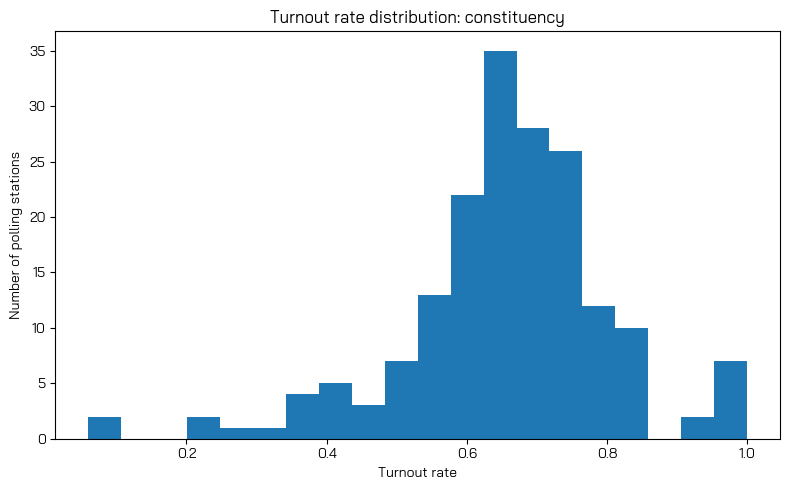

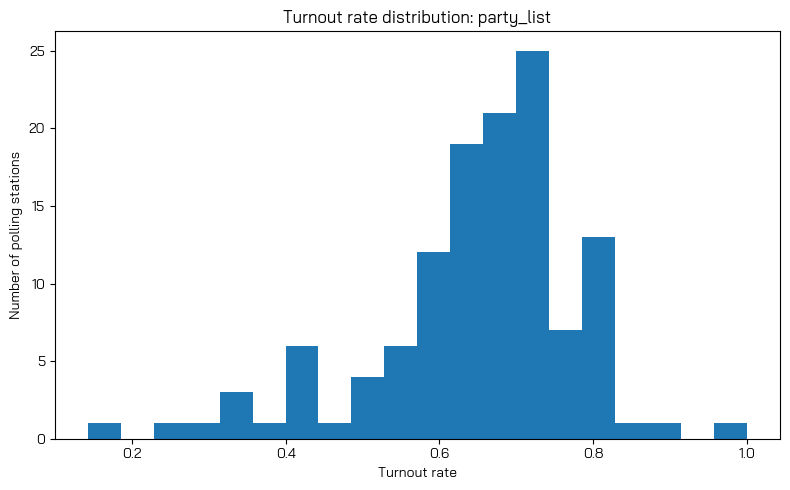

In [105]:
for name, df in [('constituency', const_station), ('party_list', party_station)]:
    plt.figure(figsize=(8, 5))
    plt.hist(df['turnout_rate'].dropna(), bins=20)
    plt.title(f'Turnout rate distribution: {name}')
    plt.xlabel('Turnout rate')
    plt.ylabel('Number of polling stations')
    plt.tight_layout()
    plt.show()

In [106]:
def subdistrict_turnout(df, election_type):
    out = df.groupby(['province','constituency','amphoe','tambon'], as_index=False).agg(
        polling_stations=('unit', 'count'),
        eligible_voters=('eligible_voters', 'sum'),
        turnout=('turnout', 'sum'),
        valid_ballots=('valid_ballots', 'sum'),
        spoiled_ballots=('spoiled_ballots', 'sum'),
        abstain_ballots=('abstain_ballots', 'sum')
    )
    out['turnout_rate'] = out['turnout'] / out['eligible_voters']
    out['spoiled_rate'] = out['spoiled_ballots'] / out['turnout']
    out['abstain_rate'] = out['abstain_ballots'] / out['turnout']
    out['election_type'] = election_type
    return out

subdistrict_turnout_all = pd.concat([
    subdistrict_turnout(const_station, 'constituency'),
    subdistrict_turnout(party_station, 'party_list')
], ignore_index=True)

display(subdistrict_turnout_all.sort_values('turnout_rate', ascending=False).head(10))
display(subdistrict_turnout_all.sort_values('turnout_rate').head(10))

,province,constituency,amphoe,tambon,polling_stations,eligible_voters,turnout,valid_ballots,spoiled_ballots,abstain_ballots,turnout_rate,spoiled_rate,abstain_rate,election_type
4,อุบลราชธานี,2,ตำบลเขื่องใน,เขตเทศบาล และนอกเขต,1,581.000,479.000,479.000,10.000,3.000,0.824,0.021,0.006,constituency
24,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,4,"1,789.000","1,437.000","1,317.000",75.000,45.000,0.803,0.052,0.031,party_list
12,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลบ้านกอก,6,"3,151.000","2,303.000","2,195.000",49.000,51.000,0.731,0.021,0.022,constituency
22,อุบลราชธานี,2,เขต 2 อ.เมืองฯ,ตำบลหนองขอน,12,"5,491.000","3,978.000","3,843.000",148.000,259.000,0.724,0.037,0.065,constituency
28,อุบลราชธานี,2,ตำบลเขื่องใน,เขตเทศบาล และนอกเขต,1,581.000,419.000,391.000,19.000,9.000,0.721,0.045,0.021,party_list
6,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลก่อเอ้,4,"1,743.000","1,239.000","1,167.000",27.000,45.000,0.711,0.022,0.036,constituency
14,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลยางขี้นก,5,"1,530.000","1,076.000","1,048.000",21.000,56.000,0.703,0.020,0.052,constituency
42,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลหนองเหล่า,4,"2,100.000","1,447.000","1,349.000",72.000,23.000,0.689,0.050,0.016,party_list
40,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลสร้างถ่อ,5,"2,000.000","1,364.000","1,232.000",59.000,53.000,0.682,0.043,0.039,party_list
0,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,9,"4,875.000","3,305.000","3,575.000",124.000,148.000,0.678,0.038,0.045,constituency


,province,constituency,amphoe,tambon,polling_stations,eligible_voters,turnout,valid_ballots,spoiled_ballots,abstain_ballots,turnout_rate,spoiled_rate,abstain_rate,election_type
20,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลแดงหม้อ,4,"1,440.000",284.000,824.000,24.000,19.000,0.197,0.085,0.067,constituency
33,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลท่าไห,8,"4,124.000","1,029.000","1,717.000",130.000,20.000,0.250,0.126,0.019,party_list
2,อุบลราชธานี,2,ตำบลหัวเรือ,ตำบลหัวเรือ,12,"6,305.000","2,071.000","4,568.000",104.000,101.000,0.328,0.050,0.049,constituency
32,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลชีทวน,4,"1,685.000",648.000,797.000,70.000,16.000,0.385,0.108,0.025,party_list
18,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลหนองเหล่า,6,"2,759.000","1,099.000","1,613.000",34.000,26.000,0.398,0.031,0.024,constituency
9,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลท่าไห,9,"5,045.000","2,061.000","2,159.000",77.000,18.000,0.409,0.037,0.009,constituency
19,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลหัวดอน,7,"3,443.000","1,515.000","2,003.000",57.000,65.000,0.440,0.038,0.043,constituency
5,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลกลางใหญ่,8,"2,846.000","1,261.000","1,502.000",42.000,26.000,0.443,0.033,0.021,constituency
36,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลบ้านกอก,5,"2,510.000","1,113.000","2,058.000",67.000,38.000,0.443,0.060,0.034,party_list
31,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลค้อทอง,5,"2,603.000","1,260.000","1,194.000",110.000,72.000,0.484,0.087,0.057,party_list


## 8. Invalid, spoiled, and abstain ballot analysis

In [107]:
for name, df in [('constituency', const_station), ('party_list', party_station)]:
    print('Highest spoiled ballot rate:', name)
    display(df.sort_values('spoiled_rate', ascending=False)[turnout_cols].head(10))
    
    print('Highest abstain ballot rate:', name)
    display(df.sort_values('abstain_rate', ascending=False)[turnout_cols].head(10))

Highest spoiled ballot rate: constituency


,province,constituency,amphoe,tambon,unit,eligible_voters,turnout,turnout_rate,valid_rate,spoiled_rate,abstain_rate
6,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,6,766.000,54.000,0.070,10.370,0.296,0.333
42,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลกลางใหญ่,5,75.000,70.000,0.933,2.843,0.171,0.071
157,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลแดงหม้อ,3,200.000,12.000,0.060,10.250,0.167,0.083
176,อุบลราชธานี,2,เขต 2 อ.เมืองฯ,ตำบลหนองขอน,6,474.000,351.000,0.741,0.917,0.140,0.057
200,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,30,548.000,393.000,0.717,0.888,0.109,0.394
207,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,37,540.000,389.000,0.720,0.884,0.105,0.388
190,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,2,694.000,456.000,0.657,0.873,0.103,0.118
214,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,44,511.000,270.000,0.528,1.174,0.078,0.119
182,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,11,497.000,374.000,0.753,0.706,0.078,0.110
216,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,5,733.000,253.000,0.345,0.814,0.071,0.115


Highest abstain ballot rate: constituency


,province,constituency,amphoe,tambon,unit,eligible_voters,turnout,turnout_rate,valid_rate,spoiled_rate,abstain_rate
64,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลชีทวน,4,629.000,421.000,0.669,0.955,0.017,0.473
200,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,30,548.000,393.000,0.717,0.888,0.109,0.394
207,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,37,540.000,389.000,0.720,0.884,0.105,0.388
6,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,6,766.000,54.000,0.070,10.370,0.296,0.333
114,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลยางขี้นก,9,257.000,183.000,0.712,0.967,0.011,0.246
217,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,6,500.000,356.000,0.712,0.980,0.025,0.222
24,อุบลราชธานี,2,ตำบลหัวเรือ,ตำบลหัวเรือ,15,402.000,92.000,0.229,3.359,0.065,0.141
194,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,23,474.000,322.000,0.679,0.848,0.022,0.130
214,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,44,511.000,270.000,0.528,1.174,0.078,0.119
190,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,2,694.000,456.000,0.657,0.873,0.103,0.118


Highest spoiled ballot rate: party_list


,province,constituency,amphoe,tambon,unit,eligible_voters,turnout,turnout_rate,valid_rate,spoiled_rate,abstain_rate
144,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,40,651.000,427.000,0.656,0.899,0.897,0.023
41,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลค้อทอง,6,480.000,321.000,0.669,0.984,0.234,0.150
64,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลนาคำใหญ่,8,504.000,296.000,0.587,0.845,0.155,0.020
143,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,4,540.000,77.000,0.143,4.506,0.143,0.260
48,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลชีทวน,7,319.000,165.000,0.517,0.836,0.133,0.030
51,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลท่าไห,10,693.000,301.000,0.434,0.890,0.106,0.003
91,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลสหธาตุ,2,393.000,235.000,0.598,0.877,0.098,0.026
50,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลท่าไห,1,546.000,173.000,0.317,1.012,0.092,0.012
59,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลธาตุน้อย,3,750.000,459.000,0.612,0.900,0.085,0.015
82,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลศรีสุข,2,520.000,320.000,0.615,0.844,0.084,0.009


Highest abstain ballot rate: party_list


,province,constituency,amphoe,tambon,unit,eligible_voters,turnout,turnout_rate,valid_rate,spoiled_rate,abstain_rate
143,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,4,540.000,77.000,0.143,4.506,0.143,0.260
41,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลค้อทอง,6,480.000,321.000,0.669,0.984,0.234,0.150
117,อุบลราชธานี,2,เขต 2 อ.เมืองฯ,ตำบลหนองขอน,7,579.000,272.000,0.470,0.923,0.062,0.107
68,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลบ้านกอก,5,507.000,154.000,0.304,2.130,0.071,0.097
139,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,36,538.000,394.000,0.732,0.886,0.025,0.089
4,อุบลราชธานี,2,ตำบลปะอาว,ตำบลปะอาว,1,370.000,293.000,0.792,0.860,0.051,0.089
138,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,34,540.000,354.000,0.656,0.890,0.031,0.079
150,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,5,733.000,253.000,0.345,0.905,0.016,0.079
5,อุบลราชธานี,2,ตำบลปะอาว,ตำบลปะอาว,2,370.000,293.000,0.792,0.874,0.051,0.075
129,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,22,480.000,319.000,0.665,0.856,0.072,0.072


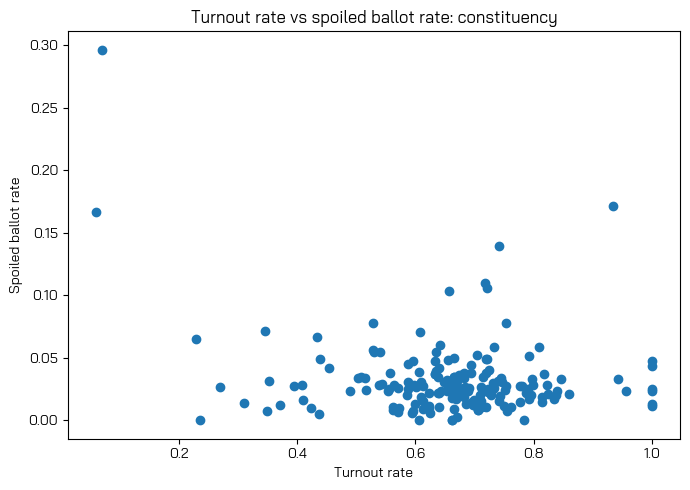

constituency correlation turnout vs spoiled: -0.24117914386133799


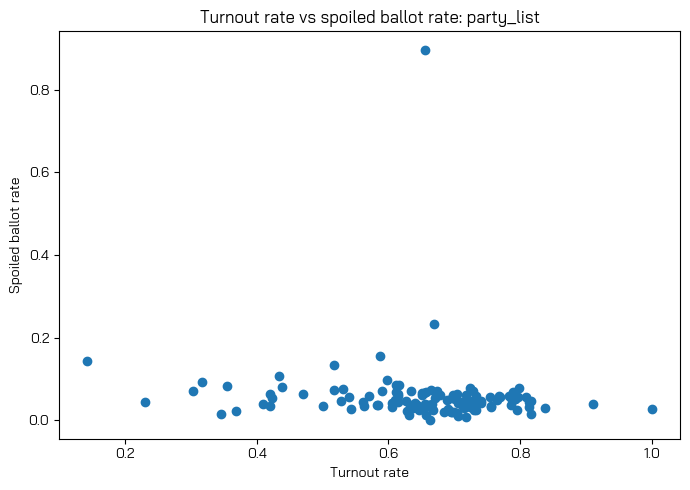

party_list correlation turnout vs spoiled: -0.09602936273035295


In [108]:
for name, df in [('constituency', const_station), ('party_list', party_station)]:
    plt.figure(figsize=(7, 5))
    plt.scatter(df['turnout_rate'], df['spoiled_rate'])
    plt.title(f'Turnout rate vs spoiled ballot rate: {name}')
    plt.xlabel('Turnout rate')
    plt.ylabel('Spoiled ballot rate')
    plt.tight_layout()
    plt.show()

    print(name, 'correlation turnout vs spoiled:', df[['turnout_rate','spoiled_rate']].corr().iloc[0,1])

## 9. Competitiveness analysis

Small winner margins indicate competitive polling stations. Large margins indicate stronghold polling stations.

In [109]:
winner_view_cols = ['province','constituency','amphoe','tambon','unit','winner_party','winner_votes','runner_up_party','runner_up_votes','margin_votes','margin_share']

print('Closest constituency polling stations')
display(const_winners.sort_values(['margin_share','margin_votes'])[winner_view_cols].head(15))

print('Largest constituency landslides')
display(const_winners.sort_values(['margin_share','margin_votes'], ascending=False)[winner_view_cols].head(15))

print('Closest party-list polling stations')
display(party_winners.sort_values(['margin_share','margin_votes'])[winner_view_cols].head(15))

print('Largest party-list landslides')
display(party_winners.sort_values(['margin_share','margin_votes'], ascending=False)[winner_view_cols].head(15))

Closest constituency polling stations


,province,constituency,amphoe,tambon,unit,winner_party,winner_votes,runner_up_party,runner_up_votes,margin_votes,margin_share
105,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลยางขี้นก,5,กล้าธรรม,0,ภูมิใจไทย,0,0,0.000
131,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลสหธาตุ,5,กล้าธรรม,0,ภูมิใจไทย,0,0,0.000
162,อุบลราชธานี,2,เขต 2 อ.เมืองฯ,ตำบลหนองขอน,4,กล้าธรรม,110,ไทรวมพลัง,110,0,0.000
164,อุบลราชธานี,2,เขต 2 อ.เมืองฯ,ตำบลหนองขอน,6,กล้าธรรม,109,ไทรวมพลัง,109,0,0.000
48,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลค้อทอง,2,ไทรวมพลัง,185,กล้าธรรม,184,1,0.003
116,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลสร้างถ่อ,13,กล้าธรรม,167,ไทรวมพลัง,166,1,0.003
160,อุบลราชธานี,2,เขต 2 อ.เมืองฯ,ตำบลหนองขอน,15,กล้าธรรม,90,ไทรวมพลัง,89,1,0.004
107,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลยางขี้นก,9,ไทรวมพลัง,85,กล้าธรรม,84,1,0.006
201,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,7,กล้าธรรม,90,ประชาชน,88,2,0.006
179,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,23,กล้าธรรม,84,ประชาชน,81,3,0.011


Largest constituency landslides


,province,constituency,amphoe,tambon,unit,winner_party,winner_votes,runner_up_party,runner_up_votes,margin_votes,margin_share
50,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลค้อทอง,4,เพื่อไทย,17,ประชาธิปไตยใหม่,2,15,0.789
65,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลท่าไห,1,กล้าธรรม,114,ไทรวมพลัง,12,102,0.750
22,อุบลราชธานี,2,ตำบลหัวเรือ,ตำบลหัวเรือ,14,ไทรวมพลัง,192,กล้าธรรม,38,154,0.583
18,อุบลราชธานี,2,ตำบลหัวเรือ,ตำบลหัวเรือ,10,ไทรวมพลัง,223,กล้าธรรม,45,178,0.578
28,อุบลราชธานี,2,ตำบลหัวเรือ,ตำบลหัวเรือ,8,ไทรวมพลัง,223,กล้าธรรม,45,178,0.578
146,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลแดงหม้อ,3,ไทรวมพลัง,87,กล้าธรรม,20,67,0.568
172,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,16,ไทรวมพลัง,262,กล้าธรรม,59,203,0.510
51,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลค้อทอง,5,กล้าธรรม,152,ไทรวมพลัง,47,105,0.500
56,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลชีทวน,10,กล้าธรรม,243,ไทรวมพลัง,72,171,0.496
68,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลท่าไห,12,ไทรวมพลัง,166,กล้าธรรม,50,116,0.489


Closest party-list polling stations


,province,constituency,amphoe,tambon,unit,winner_party,winner_votes,runner_up_party,runner_up_votes,margin_votes,margin_share
3,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,9,ไทยทรัพย์ทวี,0,เพื่อชาติไทย,0,0,0.000
7,อุบลราชธานี,2,ตำบลปะอาว,ตำบลปะอาว,6,เพื่อไทย,57,ฟิวชัน,57,0,0.000
10,อุบลราชธานี,2,ตำบลหัวเรือ,ตำบลหัวเรือ,10,เศรษฐกิจ,100,ไทรวมพลัง,100,0,0.000
46,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลชีทวน,7,ประชาธิปัตย์,20,กล้าธรรม,20,0,0.000
54,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลท่าไห,6,เพื่อไทย,69,ไทรวมพลัง,69,0,0.000
78,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลศรีสุข,1,เพื่อไทย,55,ไทรวมพลัง,55,0,0.000
63,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลบ้านกอก,1,ไทรวมพลัง,99,เพื่อไทย,98,1,0.004
69,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลบ้านไทย,3,แผ่นดินธรรม,67,ประชาชน,65,2,0.005
85,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลสร้างถ่อ,5,ประชาชน,45,กล้าธรรม,43,2,0.008
108,อุบลราชธานี,2,เขต 2 อ.เมืองฯ,ตำบลหนองขอน,6,ประชาธิปไตยใหม่,74,ประชาชน,72,2,0.009


Largest party-list landslides


,province,constituency,amphoe,tambon,unit,winner_party,winner_votes,runner_up_party,runner_up_votes,margin_votes,margin_share
88,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลสหธาตุ,6,พลังไทยรักชาติ,169,ประชาชน,30,139,0.577
80,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลศรีสุข,3,พลังไทยรักชาติ,343,เพื่อไทย,48,295,0.574
57,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลธาตุน้อย,3,พลังไทยรักชาติ,406,เพื่อไทย,59,347,0.570
86,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลสร้างถ่อ,8,ประชาธิปไตยใหม่,13,รวมใจไทย,3,10,0.556
35,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลก่อเอ้,10,พลังไทยรักชาติ,203,กล้าธรรม,36,167,0.539
131,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,38,พลังไทยรักชาติ,442,ประชาชน,116,326,0.529
75,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลยางขี้นก,6,พลังไทยรักชาติ,333,กล้าธรรม,65,268,0.508
89,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลสหธาตุ,7,ไทรวมพลัง,51,เพื่อไทย,9,42,0.483
110,อุบลราชธานี,2,เขต 2 อ.เมืองฯ,ตำบลหนองขอน,8,ประชาชน,98,ภูมิใจไทย,36,62,0.456
65,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลบ้านกอก,4,พลังไทยรักชาติ,383,เป็นธรรม,80,303,0.453


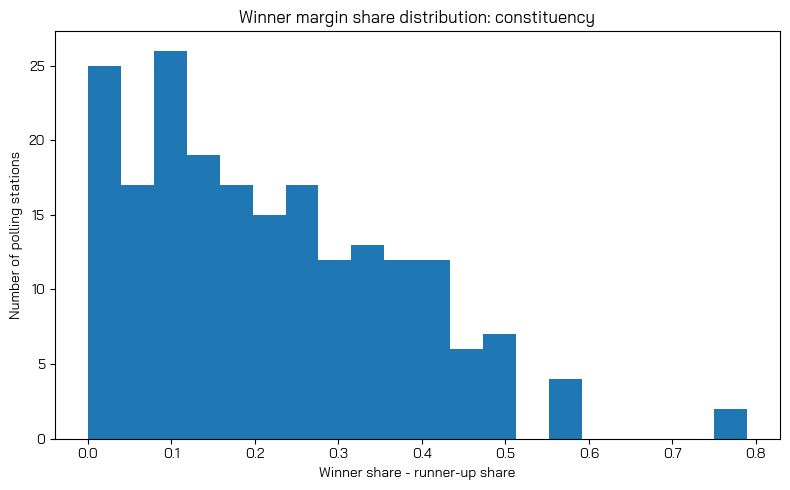

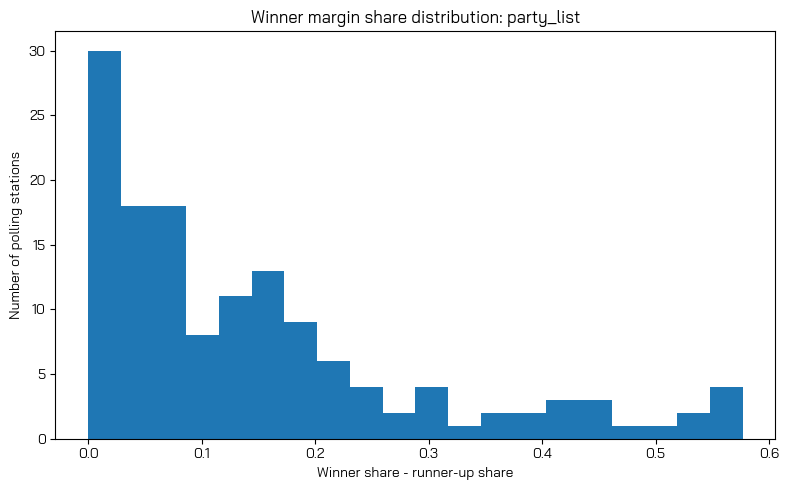

In [110]:
for name, winners in [('constituency', const_winners), ('party_list', party_winners)]:
    plt.figure(figsize=(8, 5))
    plt.hist(winners['margin_share'].dropna(), bins=20)
    plt.title(f'Winner margin share distribution: {name}')
    plt.xlabel('Winner share - runner-up share')
    plt.ylabel('Number of polling stations')
    plt.tight_layout()
    plt.show()

## 10. Stronghold analysis

A stronghold is defined here as a polling station where the winner has at least 50% vote share and wins by at least 20 percentage points.

In [111]:
def stronghold_summary(winners, election_type, min_share=0.50, min_margin=0.20):
    work = winners.copy()
    work['is_stronghold'] = (work['winner_share'] >= min_share) & (work['margin_share'] >= min_margin)
    summary = work.groupby('winner_party', as_index=False).agg(
        stations_won=('polling_station_id','nunique'),
        stronghold_stations=('is_stronghold','sum'),
        avg_winner_share=('winner_share','mean'),
        avg_margin_share=('margin_share','mean')
    )
    summary['stronghold_rate'] = summary['stronghold_stations'] / summary['stations_won']
    summary['election_type'] = election_type
    return summary.sort_values(['stronghold_stations','stations_won'], ascending=False)

strongholds = pd.concat([
    stronghold_summary(const_winners, 'constituency'),
    stronghold_summary(party_winners, 'party_list')
], ignore_index=True)

display(strongholds.groupby('election_type').head(15))

,winner_party,stations_won,stronghold_stations,avg_winner_share,avg_margin_share,stronghold_rate,election_type
0,ไทรวมพลัง,107,48,0.534,0.228,0.449,constituency
1,กล้าธรรม,77,31,0.504,0.200,0.403,constituency
2,ไทยก้าวใหม่,3,3,0.654,0.330,1.000,constituency
3,ประชาชน,15,1,0.397,0.195,0.067,constituency
4,เพื่อไทย,1,1,0.895,0.789,1.000,constituency
5,เศรษฐกิจ,1,0,0.325,0.051,0.000,constituency
6,พลังไทยรักชาติ,11,10,0.607,0.471,0.909,party_list
7,ไทรวมพลัง,33,3,0.323,0.143,0.091,party_list
8,ประชาชน,41,2,0.329,0.137,0.049,party_list
9,เพื่อไทย,22,2,0.315,0.112,0.091,party_list


## 11. Constituency vs party-list comparison

This section checks whether voters supported the same party in constituency and party-list systems at comparable geographic levels.

In [112]:
common_keys = ['province','constituency','amphoe','tambon']

const_geo_party = const_long.groupby(common_keys + ['party'], as_index=False).agg(const_votes=('votes','sum'))
party_geo_party = party_long.groupby(common_keys + ['party'], as_index=False).agg(party_list_votes=('votes','sum'))

split = const_geo_party.merge(party_geo_party, on=common_keys + ['party'], how='outer').fillna(0)
split['const_total'] = split.groupby(common_keys)['const_votes'].transform('sum')
split['party_list_total'] = split.groupby(common_keys)['party_list_votes'].transform('sum')
split['const_share'] = np.where(split['const_total'] > 0, split['const_votes'] / split['const_total'], 0)
split['party_list_share'] = np.where(split['party_list_total'] > 0, split['party_list_votes'] / split['party_list_total'], 0)
split['share_gap'] = split['const_share'] - split['party_list_share']
split['abs_share_gap'] = split['share_gap'].abs()

print('Largest party share gaps between constituency and party-list by subdistrict')
display(split.sort_values('abs_share_gap', ascending=False).head(25))

Largest party share gaps between constituency and party-list by subdistrict


,province,constituency,amphoe,tambon,party,const_votes,party_list_votes,const_total,party_list_total,const_share,party_list_share,share_gap,abs_share_gap
1236,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลโนนรัง,เพื่อไทย,23.000,209,"1,382.000",376,0.017,0.556,-0.539,0.539
626,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลธาตุน้อย,ไทรวมพลัง,"1,335.000",135,"2,403.000",1207,0.556,0.112,0.444,0.444
911,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลศรีสุข,ไทรวมพลัง,"1,026.000",136,"1,947.000",1357,0.527,0.100,0.427,0.427
799,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลยางขี้นก,กล้าธรรม,573.000,237,"1,037.000",1860,0.553,0.127,0.425,0.425
1253,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลโนนรัง,ไทรวมพลัง,564.000,0,"1,382.000",376,0.408,0.000,0.408,0.408
398,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลก่อเอ้,ไทรวมพลัง,627.000,270,"1,166.000",1841,0.538,0.147,0.391,0.391
172,อุบลราชธานี,2,ตำบลเขื่องใน,เขตตำบลเขื่องใน,กล้าธรรม,927.000,226,"1,717.000",1512,0.540,0.149,0.390,0.390
170,อุบลราชธานี,2,ตำบลหัวเรือ,ตำบลหัวเรือ,ไทรวมพลัง,"2,452.000",662,"4,588.000",3991,0.534,0.166,0.369,0.369
512,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลชีทวน,ไทรวมพลัง,"1,161.000",20,"2,947.000",619,0.394,0.032,0.362,0.362
683,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลนาคำใหญ่,ไทรวมพลัง,519.000,114,961.000,612,0.540,0.186,0.354,0.354


In [113]:
const_geo_winner = const_geo_party.sort_values(common_keys + ['const_votes'], ascending=[True, True, True, True, False]).drop_duplicates(common_keys)
party_geo_winner = party_geo_party.sort_values(common_keys + ['party_list_votes'], ascending=[True, True, True, True, False]).drop_duplicates(common_keys)

winner_compare = const_geo_winner[common_keys + ['party','const_votes']].rename(columns={'party':'constituency_winner'})
winner_compare = winner_compare.merge(
    party_geo_winner[common_keys + ['party','party_list_votes']].rename(columns={'party':'party_list_winner'}),
    on=common_keys,
    how='outer'
)
winner_compare['same_winner'] = winner_compare['constituency_winner'] == winner_compare['party_list_winner']

display(winner_compare)
print('Same winner rate:', winner_compare['same_winner'].mean())

,province,constituency,amphoe,tambon,constituency_winner,const_votes,party_list_winner,party_list_votes,same_winner
0,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,ไทรวมพลัง,1749,ไทรวมพลัง,337,True
1,อุบลราชธานี,2,ตำบลปะอาว,ตำบลปะอาว,กล้าธรรม,766,เพื่อไทย,294,False
2,อุบลราชธานี,2,ตำบลหัวเรือ,ตำบลหัวเรือ,ไทรวมพลัง,2452,ไทรวมพลัง,662,True
3,อุบลราชธานี,2,ตำบลเขื่องใน,เขตตำบลเขื่องใน,กล้าธรรม,927,ไทรวมพลัง,233,False
4,อุบลราชธานี,2,ตำบลเขื่องใน,เขตเทศบาล และนอกเขต,กล้าธรรม,217,เพื่อไทย,99,False
5,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลกลางใหญ่,กล้าธรรม,784,กล้าธรรม,305,True
6,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลก่อเอ้,ไทรวมพลัง,627,ไทรวมพลัง,270,True
7,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลค้อทอง,กล้าธรรม,980,กล้าธรรม,211,True
8,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลชีทวน,กล้าธรรม,1529,กล้าธรรม,144,True
9,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลท่าไห,ไทรวมพลัง,1132,ไทรวมพลัง,453,True


Same winner rate: 0.4166666666666667


In [114]:
winner_crosstab = pd.crosstab(winner_compare['constituency_winner'], winner_compare['party_list_winner'])
display(winner_crosstab)

party_list_winner,กล้าธรรม,ประชาชน,พลังไทยรักชาติ,เพื่อไทย,ไทรวมพลัง
constituency_winner,,,,,
กล้าธรรม,3,1,1,3,3
ประชาชน,0,1,0,0,0
ไทรวมพลัง,0,1,4,1,6


## 12. Party concentration analysis

This finds whether each party's votes are spread out or concentrated in a few polling stations.

In [115]:
def concentration_analysis(long_df):
    work = long_df.copy()
    total_by_party = work.groupby('party')['votes'].transform('sum')
    work['party_vote_fraction_from_station'] = np.where(total_by_party > 0, work['votes'] / total_by_party, 0)
    result = work.groupby(['election_type','party'], as_index=False).agg(
        total_votes=('votes','sum'),
        max_station_votes=('votes','max'),
        max_station_fraction=('party_vote_fraction_from_station','max'),
        avg_station_votes=('votes','mean'),
        std_station_votes=('votes','std')
    )
    result['coefficient_of_variation'] = result['std_station_votes'] / result['avg_station_votes'].replace(0, np.nan)
    return result.sort_values(['election_type','max_station_fraction'], ascending=[True, False])

concentration = concentration_analysis(all_long)
display(concentration.groupby('election_type').head(20))

,election_type,party,total_votes,max_station_votes,max_station_fraction,avg_station_votes,std_station_votes,coefficient_of_variation
8,constituency,ไทยก้าวใหม่,701,255,0.316,3.436,23.781,6.921
4,constituency,พลังประชารัฐ,255,28,0.069,1.250,2.887,2.310
7,constituency,เศรษฐกิจ,841,147,0.063,4.123,10.946,2.655
3,constituency,ประชาธิปไตยใหม่,225,15,0.017,1.103,1.683,1.526
5,constituency,ภูมิใจไทย,1601,82,0.015,7.848,11.544,1.471
0,constituency,กล้าธรรม,21976,351,0.014,107.725,56.724,0.527
1,constituency,ประชาชน,7512,197,0.013,36.824,38.277,1.039
2,constituency,ประชาธิปัตย์,417,18,0.011,2.044,3.018,1.476
9,constituency,ไทรวมพลัง,24934,325,0.011,122.225,68.548,0.561
6,constituency,เพื่อไทย,2549,69,0.008,12.495,13.386,1.071


## 13. Outlier detection

This flags polling stations with unusual turnout, spoiled ballot rate, abstain rate, or OCR validation differences using z-scores.

In [116]:
def add_outlier_flags(df, election_type):
    work = df.copy()
    metrics = ['turnout_rate', 'spoiled_rate', 'abstain_rate', 'ocr_vote_diff_abs']
    for col in metrics:
        mu = work[col].mean()
        sigma = work[col].std()
        work[col + '_z'] = (work[col] - mu) / sigma if sigma and sigma > 0 else 0
    work['outlier_score'] = work[[m + '_z' for m in metrics]].abs().sum(axis=1)
    work['election_type'] = election_type
    return work

outliers = pd.concat([
    add_outlier_flags(const_station, 'constituency'),
    add_outlier_flags(party_station, 'party_list')
], ignore_index=True)

outlier_cols = ['election_type','province','constituency','amphoe','tambon','unit','turnout_rate','spoiled_rate','abstain_rate','ocr_vote_diff_abs','outlier_score']
display(outliers.sort_values('outlier_score', ascending=False)[outlier_cols].head(25))

,election_type,province,constituency,amphoe,tambon,unit,turnout_rate,spoiled_rate,abstain_rate,ocr_vote_diff_abs,outlier_score
6,constituency,อุบลราชธานี,2,ตำบลขี้เหล็ก,ตำบลขี้เหล็ก,6,0.070,0.296,0.333,0,16.707
136,constituency,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลหนองเหล่า,8,0.783,0.000,0.000,419,14.036
337,party_list,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,4,0.143,0.143,0.260,60,11.922
338,party_list,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,40,0.656,0.897,0.023,0,11.272
146,constituency,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลแดงหม้อ,3,0.060,0.167,0.083,5,8.829
334,party_list,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,37,NaN,NaN,NaN,861,8.732
185,constituency,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,30,0.717,0.109,0.394,0,8.321
192,constituency,อุบลราชธานี,2,เขตไร่น้อย,เขตไร่น้อย,37,0.720,0.105,0.388,0,8.123
60,constituency,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลชีทวน,4,0.669,0.017,0.473,0,7.245
40,constituency,อุบลราชธานี,2,อำเภอเขื่องใน,ตำบลกลางใหญ่,5,0.933,0.171,0.071,15,6.711


## 14. Optional clustering of polling stations

This groups polling stations by voting behavior and ballot-quality metrics. The exact cluster labels are not meaningful by themselves; interpret them using the cluster profile table.

Constituency cluster profile


,cluster,polling_stations,avg_turnout_rate,avg_spoiled_rate,avg_abstain_rate,avg_share_ไทรวมพลัง,avg_share_กล้าธรรม,avg_share_ประชาชน,avg_share_เพื่อไทย,avg_share_ภูมิใจไทย,avg_share_เศรษฐกิจ,avg_share_ไทยก้าวใหม่,avg_share_ประชาธิปัตย์
0,0,41,0.653,0.047,0.104,0.224,0.256,0.283,0.111,0.074,0.028,0.005,0.019
1,1,93,0.482,0.023,0.018,0.546,0.299,0.078,0.029,0.011,0.010,0.001,0.004
2,2,67,0.664,0.026,0.032,0.334,0.541,0.070,0.030,0.013,0.007,0.001,0.003
3,3,3,0.702,0.000,0.000,0.324,0.001,0.006,0.007,0.003,0.003,0.654,0.003


Party-list cluster profile


,cluster,polling_stations,avg_turnout_rate,avg_spoiled_rate,avg_abstain_rate,avg_share_ประชาชน,avg_share_เพื่อไทย,avg_share_ไทรวมพลัง,avg_share_ภูมิใจไทย,avg_share_พลังไทยรักชาติ,avg_share_กล้าธรรม,avg_share_เศรษฐกิจ,avg_share_รวมใจไทย
0,0,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
1,1,63,0.589,0.059,0.024,0.140,0.230,0.302,0.070,0.005,0.102,0.072,0.065
2,2,11,0.437,0.032,0.017,0.095,0.035,0.029,0.049,0.699,0.063,0.010,0.020
3,3,67,0.576,0.045,0.037,0.325,0.188,0.088,0.170,0.003,0.142,0.038,0.045


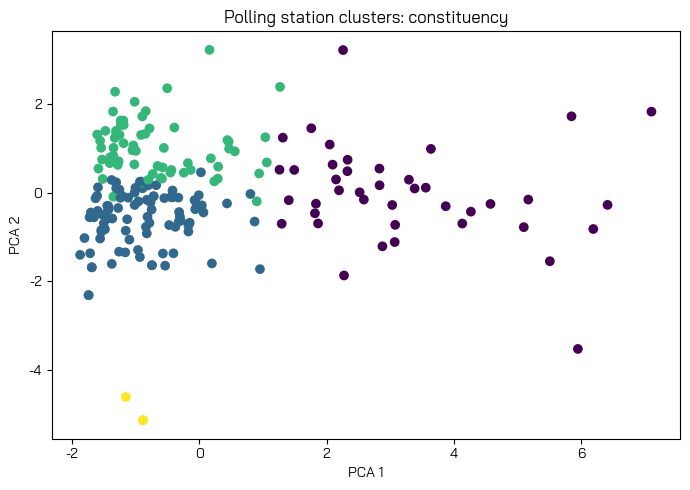

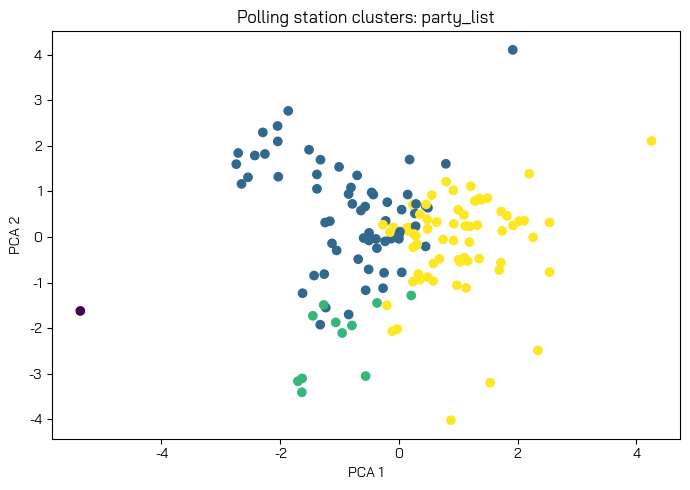

In [117]:
try:
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA

    def cluster_polling_stations(long_df, station_df, election_type, top_n_parties=8, k=4):
        top_parties = long_df.groupby('party')['votes'].sum().sort_values(ascending=False).head(top_n_parties).index.tolist()
        work = long_df[long_df['party'].isin(top_parties)].copy()
        work['station_total_votes'] = work.groupby('polling_station_id')['votes'].transform('sum')
        work['vote_share'] = np.where(work['station_total_votes'] > 0, work['votes'] / work['station_total_votes'], 0)
        share_wide = work.pivot_table(index='polling_station_id', columns='party', values='vote_share', fill_value=0)

        station_features = station_df.copy()
        station_features['polling_station_id'] = (
            station_features['province'].astype(str) + '|' +
            station_features['constituency'].astype(str) + '|' +
            station_features['amphoe'].astype(str) + '|' +
            station_features['tambon'].astype(str) + '|' +
            station_features['unit'].astype(str)
        )
        station_features = station_features.set_index('polling_station_id')
        metrics = station_features[['turnout_rate','spoiled_rate','abstain_rate']]
        X = share_wide.join(metrics, how='left').fillna(0)

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        model = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = model.fit_predict(X_scaled)

        clustered = X.copy()
        clustered['cluster'] = labels
        clustered = clustered.join(station_features[['province','constituency','amphoe','tambon','unit']], how='left')
        clustered['election_type'] = election_type

        profile = clustered.groupby('cluster').agg(
            polling_stations=('cluster','count'),
            avg_turnout_rate=('turnout_rate','mean'),
            avg_spoiled_rate=('spoiled_rate','mean'),
            avg_abstain_rate=('abstain_rate','mean')
        )
        for p in top_parties:
            profile[f'avg_share_{p}'] = clustered.groupby('cluster')[p].mean()
        profile = profile.reset_index()

        pca = PCA(n_components=2, random_state=42)
        coords = pca.fit_transform(X_scaled)
        clustered['pca_1'] = coords[:, 0]
        clustered['pca_2'] = coords[:, 1]
        return clustered.reset_index(), profile

    const_clusters, const_cluster_profile = cluster_polling_stations(const_long, const_station, 'constituency', top_n_parties=8, k=4)
    party_clusters, party_cluster_profile = cluster_polling_stations(party_long, party_station, 'party_list', top_n_parties=8, k=4)

    print('Constituency cluster profile')
    display(const_cluster_profile)
    print('Party-list cluster profile')
    display(party_cluster_profile)

    for name, clustered in [('constituency', const_clusters), ('party_list', party_clusters)]:
        plt.figure(figsize=(7, 5))
        plt.scatter(clustered['pca_1'], clustered['pca_2'], c=clustered['cluster'])
        plt.title(f'Polling station clusters: {name}')
        plt.xlabel('PCA 1')
        plt.ylabel('PCA 2')
        plt.tight_layout()
        plt.show()

except Exception as e:
    print('Clustering skipped:', e)

## 15. Auto-generate insight candidates

Use these as starting points for the written analysis and dashboard story.

In [118]:
insights = []

for election_type, df in [('constituency', const_station), ('party_list', party_station)]:
    avg_turnout = df['turnout'].sum() / df['eligible_voters'].sum()
    avg_spoiled = df['spoiled_ballots'].sum() / df['turnout'].sum()
    avg_abstain = df['abstain_ballots'].sum() / df['turnout'].sum()
    insights.append({
        'theme': 'overall_participation',
        'election_type': election_type,
        'insight': f'{election_type} turnout rate is {avg_turnout:.2%}, spoiled ballot rate is {avg_spoiled:.2%}, and abstain rate is {avg_abstain:.2%}.'
    })

for election_type in party_perf['election_type'].unique():
    top = party_perf[party_perf['election_type'] == election_type].iloc[0]
    insights.append({
        'theme': 'party_dominance',
        'election_type': election_type,
        'insight': f'{top.party} is the leading party in {election_type} with {top.votes:,.0f} votes ({top.vote_share:.2%}).'
    })

same_winner_rate = winner_compare['same_winner'].mean()
insights.append({
    'theme': 'split_ticket',
    'election_type': 'comparison',
    'insight': f'Constituency and party-list winners are the same in {same_winner_rate:.2%} of comparable subdistricts.'
})

close_const = (const_winners['margin_share'] <= 0.05).mean()
close_party = (party_winners['margin_share'] <= 0.05).mean()
insights.append({
    'theme': 'competitiveness',
    'election_type': 'constituency',
    'insight': f'{close_const:.2%} of constituency polling stations have a winner margin of 5 percentage points or less.'
})
insights.append({
    'theme': 'competitiveness',
    'election_type': 'party_list',
    'insight': f'{close_party:.2%} of party-list polling stations have a winner margin of 5 percentage points or less.'
})

insight_df = pd.DataFrame(insights)
display(insight_df)

,theme,election_type,insight
0,overall_participation,constituency,"constituency turnout rate is 57.44%, spoiled b..."
1,overall_participation,party_list,"party_list turnout rate is 57.33%, spoiled bal..."
2,party_dominance,constituency,ไทรวมพลัง is the leading party in constituency...
3,party_dominance,party_list,ประชาชน is the leading party in party_list wit...
4,split_ticket,comparison,Constituency and party-list winners are the sa...
5,competitiveness,constituency,14.71% of constituency polling stations have a...
6,competitiveness,party_list,29.58% of party-list polling stations have a w...


## 16. Export analysis outputs for dashboard

These CSV files can be imported into Power BI, Tableau, Looker Studio, Streamlit, or Plotly Dash.

In [119]:
OUTPUT_DIR = Path('analysis_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

summary.to_csv(OUTPUT_DIR / 'overall_summary.csv', index=False)
turnout_year_summary.to_csv(OUTPUT_DIR / 'turnout_year_summary.csv', index=False)
turnout_change.to_csv(OUTPUT_DIR / 'turnout_change_2566_vs_recent.csv', index=False)
party_perf.to_csv(OUTPUT_DIR / 'party_performance.csv', index=False)
subdistrict_turnout_all.to_csv(OUTPUT_DIR / 'subdistrict_turnout.csv', index=False)
const_winners.to_csv(OUTPUT_DIR / 'constituency_station_winners.csv', index=False)
party_winners.to_csv(OUTPUT_DIR / 'party_list_station_winners.csv', index=False)
split.to_csv(OUTPUT_DIR / 'constituency_vs_party_list_party_gap.csv', index=False)
winner_compare.to_csv(OUTPUT_DIR / 'constituency_vs_party_list_winner_compare.csv', index=False)
strongholds.to_csv(OUTPUT_DIR / 'strongholds.csv', index=False)
outliers[outlier_cols].to_csv(OUTPUT_DIR / 'outliers.csv', index=False)
insight_df.to_csv(OUTPUT_DIR / 'insight_candidates.csv', index=False)
const_year_comparison.to_csv(OUTPUT_DIR / 'constituency_year_comparison.csv', index=False)
party_year_comparison.to_csv(OUTPUT_DIR / 'party_list_year_comparison.csv', index=False)
tambon_winner_change.to_csv(OUTPUT_DIR / 'tambon_winner_change.csv', index=False)

try:
    const_clusters.to_csv(OUTPUT_DIR / 'constituency_clusters.csv', index=False)
    party_clusters.to_csv(OUTPUT_DIR / 'party_list_clusters.csv', index=False)
    const_cluster_profile.to_csv(OUTPUT_DIR / 'constituency_cluster_profile.csv', index=False)
    party_cluster_profile.to_csv(OUTPUT_DIR / 'party_list_cluster_profile.csv', index=False)
except NameError:
    pass

print('Exported files:')
for path in sorted(OUTPUT_DIR.glob('*.csv')):
    print(path)

Exported files:
analysis_outputs/constituency_cluster_profile.csv
analysis_outputs/constituency_clusters.csv
analysis_outputs/constituency_station_winners.csv
analysis_outputs/constituency_vs_party_list_party_gap.csv
analysis_outputs/constituency_vs_party_list_winner_compare.csv
analysis_outputs/constituency_year_comparison.csv
analysis_outputs/insight_candidates.csv
analysis_outputs/outliers.csv
analysis_outputs/overall_summary.csv
analysis_outputs/party_list_cluster_profile.csv
analysis_outputs/party_list_clusters.csv
analysis_outputs/party_list_station_winners.csv
analysis_outputs/party_list_year_comparison.csv
analysis_outputs/party_performance.csv
analysis_outputs/strongholds.csv
analysis_outputs/subdistrict_turnout.csv
analysis_outputs/tambon_winner_change.csv
analysis_outputs/turnout_change_2566_vs_recent.csv
analysis_outputs/turnout_year_summary.csv


## 17. How the analysis becomes the Streamlit dashboard

The Streamlit dashboard is built from the main analytical findings above:

1. **Map comparison**: uses tambon winner tables to show geographic winner changes between ปี66 and ปีนี้.
2. **Dumbbell chart**: uses party year-comparison tables to show vote increases and decreases.
3. **Grouped bar chart**: compares constituency and party-list support in the recent election.
4. **Treemap and sunburst**: use polling-unit winners to show local strongholds and vote concentration.
5. **Raw and summary pages**: keep the analysis transparent by exposing the cleaned source data and aggregate totals.

This means the dashboard is not only visualization; it is the presentation layer of the data science workflow: validation, feature engineering, comparison, geographic analysis, and insight generation.
